In [1]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from datasets import Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import random
import torch
import warnings
import os

warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

# seed set
SEED = 2025
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

In [2]:
model_name = "monologg/kobert"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

# torken set
tokenizer.eos_token = "[SEP]"
tokenizer.eos_token_id = 3

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=7)

BertForSequenceClassification LOAD REPORT from: monologg/kobert
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [3]:
def preprocess_fn(examples):
    inputs = [str(t).strip().rstrip('.') for t in examples["text"]]

    return tokenizer(
        inputs,
        truncation=True,
        padding="max_length",
        max_length=128,
        add_special_tokens=True
    )

def compute_metrics(pred):
    labels = pred.label_ids

    if isinstance(pred.predictions, tuple):
        logits = pred.predictions[0]
    else:
        logits = pred.predictions

    preds = logits.argmax(-1)

    acc = accuracy_score(labels, preds)
    precision_res, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )
    return {'accuracy': acc, 'f1': f1, 'recall':recall, 'precision':precision_res}

In [4]:
# train_data load
try:
    train_df = pd.read_csv("target_kobert_train_data.tsv", sep='\t')
    train_df = train_df.rename(columns={'target_text': 'text', 'emotion_id': 'label'})
    print(f"train data load: {len(train_df)}")
except FileNotFoundError as e:
    print(f"Error: {e}")

train data load: 43975


In [5]:
train_df = train_df[['input_text', 'emotion']]

# 3. col name change
train_df = train_df.rename(columns={'input_text': 'text', 'emotion': 'labels'})

# 4. 문자열 감정을 숫자로 매핑 (연구원님의 감정 체계에 맞게 수정)
# 70개 실증 데이터와 동일한 숫자를 부여해야 전이 학습이 가능합니다.
emotion_map = {
    'happy': 0,
    'neutral': 1,
    'fearful': 2,
    'disgust': 3,
    'surprise': 4,
    'sad': 5,
    'angry': 6,
}

train_df['labels'] = train_df['labels'].map(emotion_map)

# Remove Nan
train_df = train_df.dropna(subset=['labels']).reset_index(drop=True)
train_df['labels'] = train_df['labels'].astype(int)

df = pd.read_csv('./test_data.csv')
test_df = df[['text', 'label']]

In [6]:
train_ds = Dataset.from_pandas(train_df).map(preprocess_fn, batched=True)
val_fold_ds = Dataset.from_pandas(test_df).map(preprocess_fn, batched=True)

training_args = TrainingArguments(
    seed=SEED,
    output_dir=f"./kobert_result",
    num_train_epochs=100,
    per_device_train_batch_size=32,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,

    # --- 최고 성능 모델 저장을 위한 설정 ---
    eval_strategy="epoch",    # 매 에폭마다 평가
    save_strategy="epoch",          # 매 에폭마다 저장
    load_best_model_at_end=True,    # 학습 종료 후 가장 좋은 모델 로드
    metric_for_best_model="accuracy", # 어떤 지표를 기준으로 할지
    greater_is_better=True,         # 정확도는 높을수록 좋으므로 True
    save_total_limit=1,             # 최고 모델 1개만 남기고 나머지는 자동 삭제 (용량 절약)
    # ------------------------------------
    label_smoothing_factor=0.1,
    fp16=True,
    gradient_checkpointing=True,
    logging_steps=10
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_fold_ds,
    compute_metrics=compute_metrics
)

trainer.train()
eval_result = trainer.evaluate()
pred_result = trainer.predict(val_fold_ds)

In [7]:
eval_result

{'eval_loss': 2.4236602783203125,
 'eval_accuracy': 0.44285714285714284,
 'eval_f1': 0.3847342995169082,
 'eval_recall': 0.44285714285714295,
 'eval_precision': 0.36824960753532177,
 'eval_runtime': 0.1254,
 'eval_samples_per_second': 558.343,
 'eval_steps_per_second': 71.787,
 'epoch': 100.0}

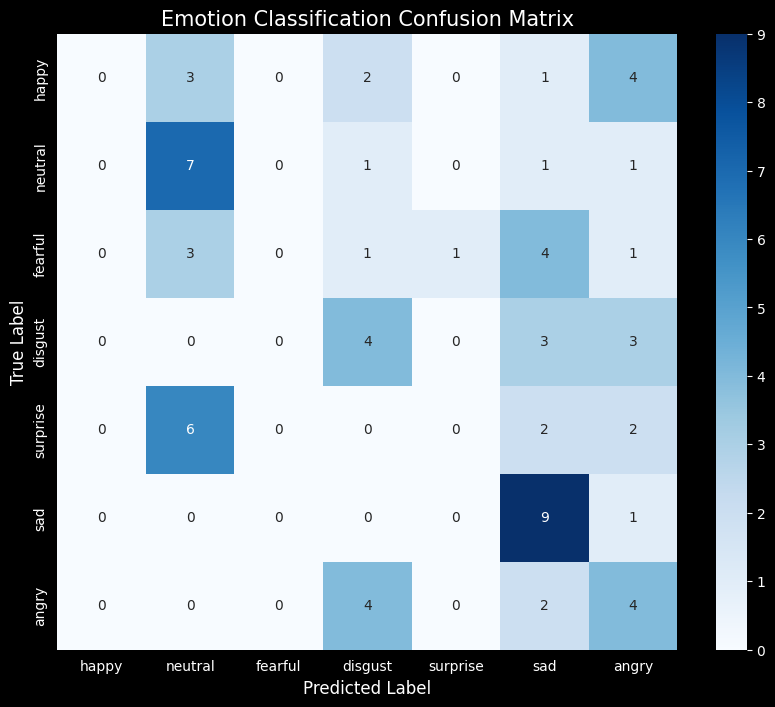

In [17]:
target_names = ['happy', 'neutral', 'fearful', 'disgust', 'surprise', 'sad', 'angry']
count = 1
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)

plt.title(f'Emotion Classification Confusion Matrix', fontsize=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()
count+=1